In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib
import os



In [2]:
df = pd.read_csv("loan_sanction_train.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'loan_sanction_train.csv'

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
#fill missing values
df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)
df["Married"].fillna(df["Married"].mode()[0],inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0],inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0],inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0],inplace=True)
df["LoanAmount"].fillna(df["LoanAmount"].median(),inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median(),inplace=True)


/tmp/ipykernel_286/2491141675.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)
/tmp/ipykernel_286/2491141675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
df.isnull().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


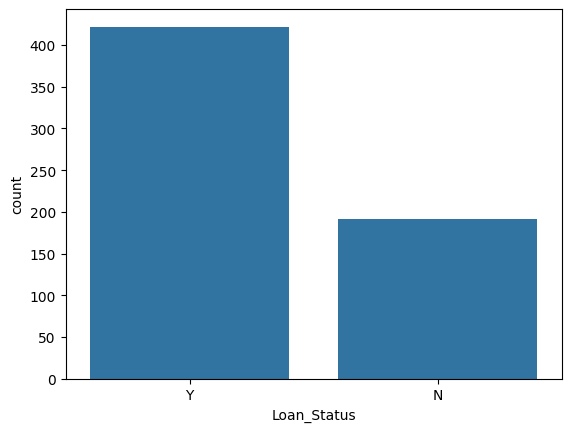

In [ ]:
sns.countplot(x="Loan_Status", data=df)
plt.show()

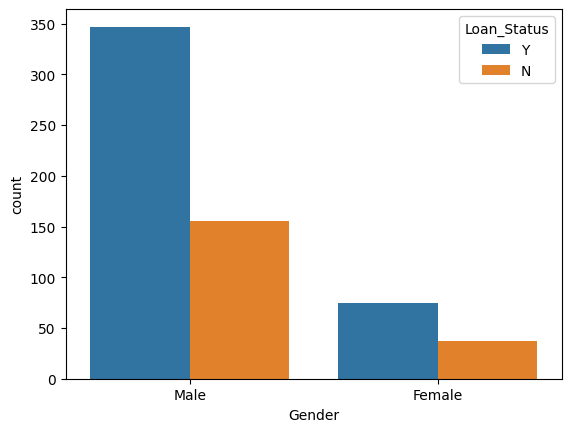

In [ ]:
#Gender vs Loan Status
sns.countplot(x="Gender", hue="Loan_Status", data=df)
plt.show()

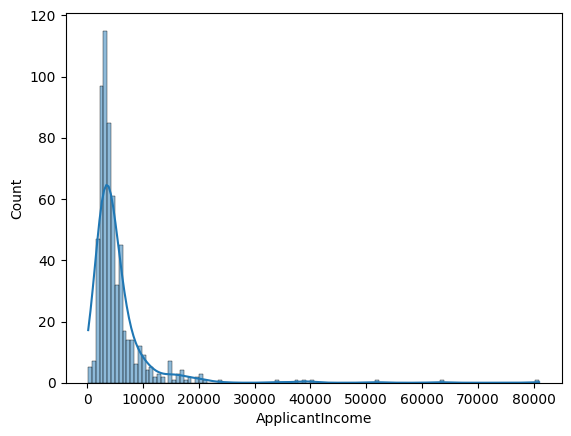

In [ ]:
#Applicant Income Distribution
sns.histplot(df["ApplicantIncome"], kde=True)
plt.show()

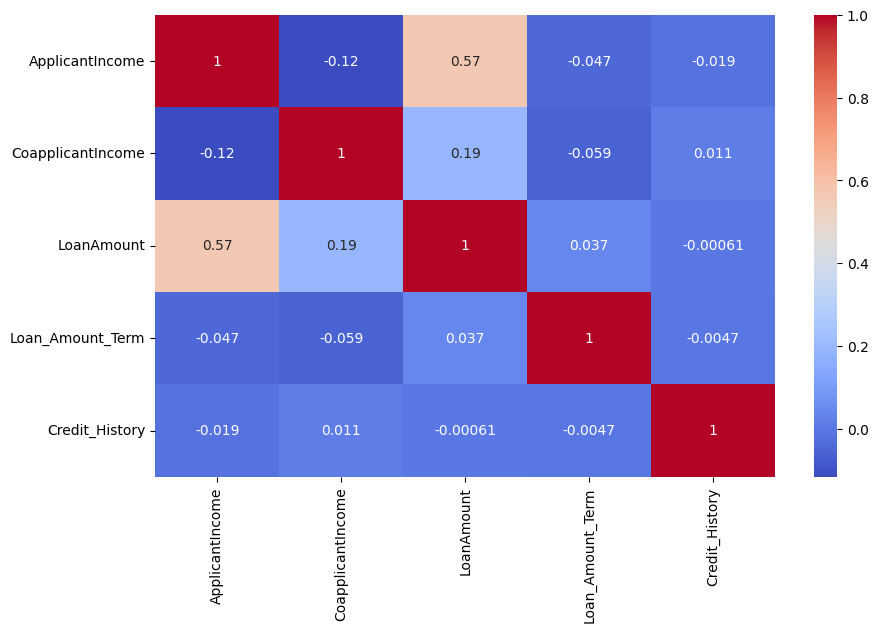

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
#coverting categorical data to numerical data
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})
df["Married"] = df["Married"].map({"Yes":1, "No":0})
df["Education"] = df["Education"].map({"Graduate":1, "Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes":1, "No":0})

df = pd.get_dummies(df, columns=["Property_Area"], drop_first=True)

In [ ]:
#replace the values fo row
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = df["Dependents"].astype(int)

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Y,False,True
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,False,False
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Y,False,True
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Y,False,True
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Y,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,Y,False,False
610,LP002979,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,Y,False,False
611,LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,Y,False,True
612,LP002984,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,Y,False,True


In [ ]:
x = df.drop(["Loan_ID","Loan_Status"],axis=1)
y = df["Loan_Status"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores: [0.81300813 0.77235772 0.7804878  0.84552846 0.81147541]
Mean CV Accuracy: 0.8045715047314408


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR training accuracy = 0.8187372708757638
LR testing accuracy = 0.7886178861788617
              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



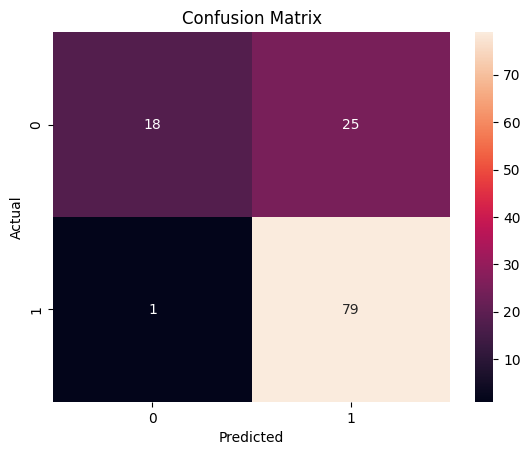

In [ ]:
# logistic regression
model = LogisticRegression(max_iter=1000)



cv_scores = cross_val_score(model, x, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

model.fit(x_train,y_train)



train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train,train_pred)
print("LR training accuracy =",train_accuracy)

test_pred = model.predict(x_test)
test_accuracy = accuracy_score(y_test,test_pred)
print("LR testing accuracy =",test_accuracy)

print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test,test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
## random_forest_
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    random_state=42
)
model.fit(x_train,y_train)

train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train,train_pred)
print("random forest training accuracy =",train_accuracy)

test_pred = model.predict(x_test)
test_accuracy = accuracy_score(y_test,test_pred)
print("random forest testing accuracy =",test_accuracy)

print(classification_report(y_test, test_pred))


random forest training accuracy = 0.835030549898167
random forest testing accuracy = 0.7886178861788617
              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [1]:
import pandas as pd

# take user inputs
gender = int(input("Gender (Male=1, Female=0): "))
married = int(input("Married (Yes=1, No=0): "))
dependents = int(input("Dependents (0,1,2,3): "))
education = int(input("Education (Graduate=1, Not Graduate=0): "))
self_employed = int(input("Self Employed (Yes=1, No=0): "))
app_income = float(input("Applicant Income: "))
coapp_income = float(input("Coapplicant Income: "))
loan_amount = float(input("Loan Amount: "))
loan_term = float(input("Loan Amount Term: "))
credit_history = int(input("Credit History (1=good, 0=bad): "))

property_area = input("Property Area (Urban/Semiurban/Rural): ").lower()

# convert property area to dummy variables
property_area_semiurban = 0
property_area_urban = 0

if property_area == "semiurban":
    property_area_semiurban = 1
elif property_area == "urban":
    property_area_urban = 1

# create dataframe
user_data = pd.DataFrame([[
    gender,
    married,
    dependents,
    education,
    self_employed,
    app_income,
    coapp_income,
    loan_amount,
    loan_term,
    credit_history,
    property_area_semiurban,
    property_area_urban
]], columns=[
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area_Semiurban",
    "Property_Area_Urban"
])

# make prediction
prediction = model.predict(user_data)

if prediction[0] == 'Y':
    print("\nLoan Approved ✅")
else:
    print("\nLoan Rejected ❌")

ValueError: invalid literal for int() with base 10: ''